<a href="https://colab.research.google.com/github/veernaik/Data_Science_16014324004_TY/blob/main/exp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Saving weatherAUS.csv to weatherAUS (2).csv
Dataset loaded successfully
Dataset shape: (145460, 23)

First 5 rows:
         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0 

Inference: The dataset was successfully loaded with 145,460 rows and 23 columns. It contains numerical weather variables such as MinTemp, MaxTemp, Rainfall, Humidity and Pressure for analysis.

In [ ]:
numeric_data = df.select_dtypes(include=np.number)

print("Selected numerical attributes:")
print(numeric_data.columns.tolist())

print("\nSelected data:")
print(numeric_data.head())

Selected numerical attributes:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Selected data:
   MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
0     13.4     22.9       0.6          NaN       NaN           44.0   
1      7.4     25.1       0.0          NaN       NaN           44.0   
2     12.9     25.7       0.0          NaN       NaN           46.0   
3      9.2     28.0       0.0          NaN       NaN           24.0   
4     17.5     32.3       1.0          NaN       NaN           41.0   

   WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  \
0          20.0          24.0         71.0         22.0       1007.7   
1           4.0          22.0         44.0         25.0       1010.6   
2          19.0          26.0         38.0         30.0       1007.6   
3          11.0      

Inference: The numerical attributes include 16 variables, such as MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, Humidity and Pressure. These variables were selected for statistical and distribution analysis.

In [ ]:
print("Mean:")
print(numeric_data.mean())

print("\nMedian:")
print(numeric_data.median())

print("\nStandard Deviation:")
print(numeric_data.std())

Mean:
MinTemp            12.194034
MaxTemp            23.221348
Rainfall            2.360918
Evaporation         5.468232
Sunshine            7.611178
WindGustSpeed      40.035230
WindSpeed9am       14.043426
WindSpeed3pm       18.662657
Humidity9am        68.880831
Humidity3pm        51.539116
Pressure9am      1017.649940
Pressure3pm      1015.255889
Cloud9am            4.447461
Cloud3pm            4.509930
Temp9am            16.990631
Temp3pm            21.683390
dtype: float64

Median:
MinTemp            12.0
MaxTemp            22.6
Rainfall            0.0
Evaporation         4.8
Sunshine            8.4
WindGustSpeed      39.0
WindSpeed9am       13.0
WindSpeed3pm       19.0
Humidity9am        70.0
Humidity3pm        52.0
Pressure9am      1017.6
Pressure3pm      1015.2
Cloud9am            5.0
Cloud3pm            5.0
Temp9am            16.7
Temp3pm            21.1
dtype: float64

Standard Deviation:
MinTemp           6.398495
MaxTemp           7.119049
Rainfall          8.478060
Evapo

Inference: MinTemp has a mean of 12.19, median 12.0 and standard deviation 6.40, while MaxTemp has a mean of 23.22, median 22.6 and standard deviation 7.12. Rainfall has a mean of 2.36, median 0.0 and standard deviation 8.48, showing high variation.

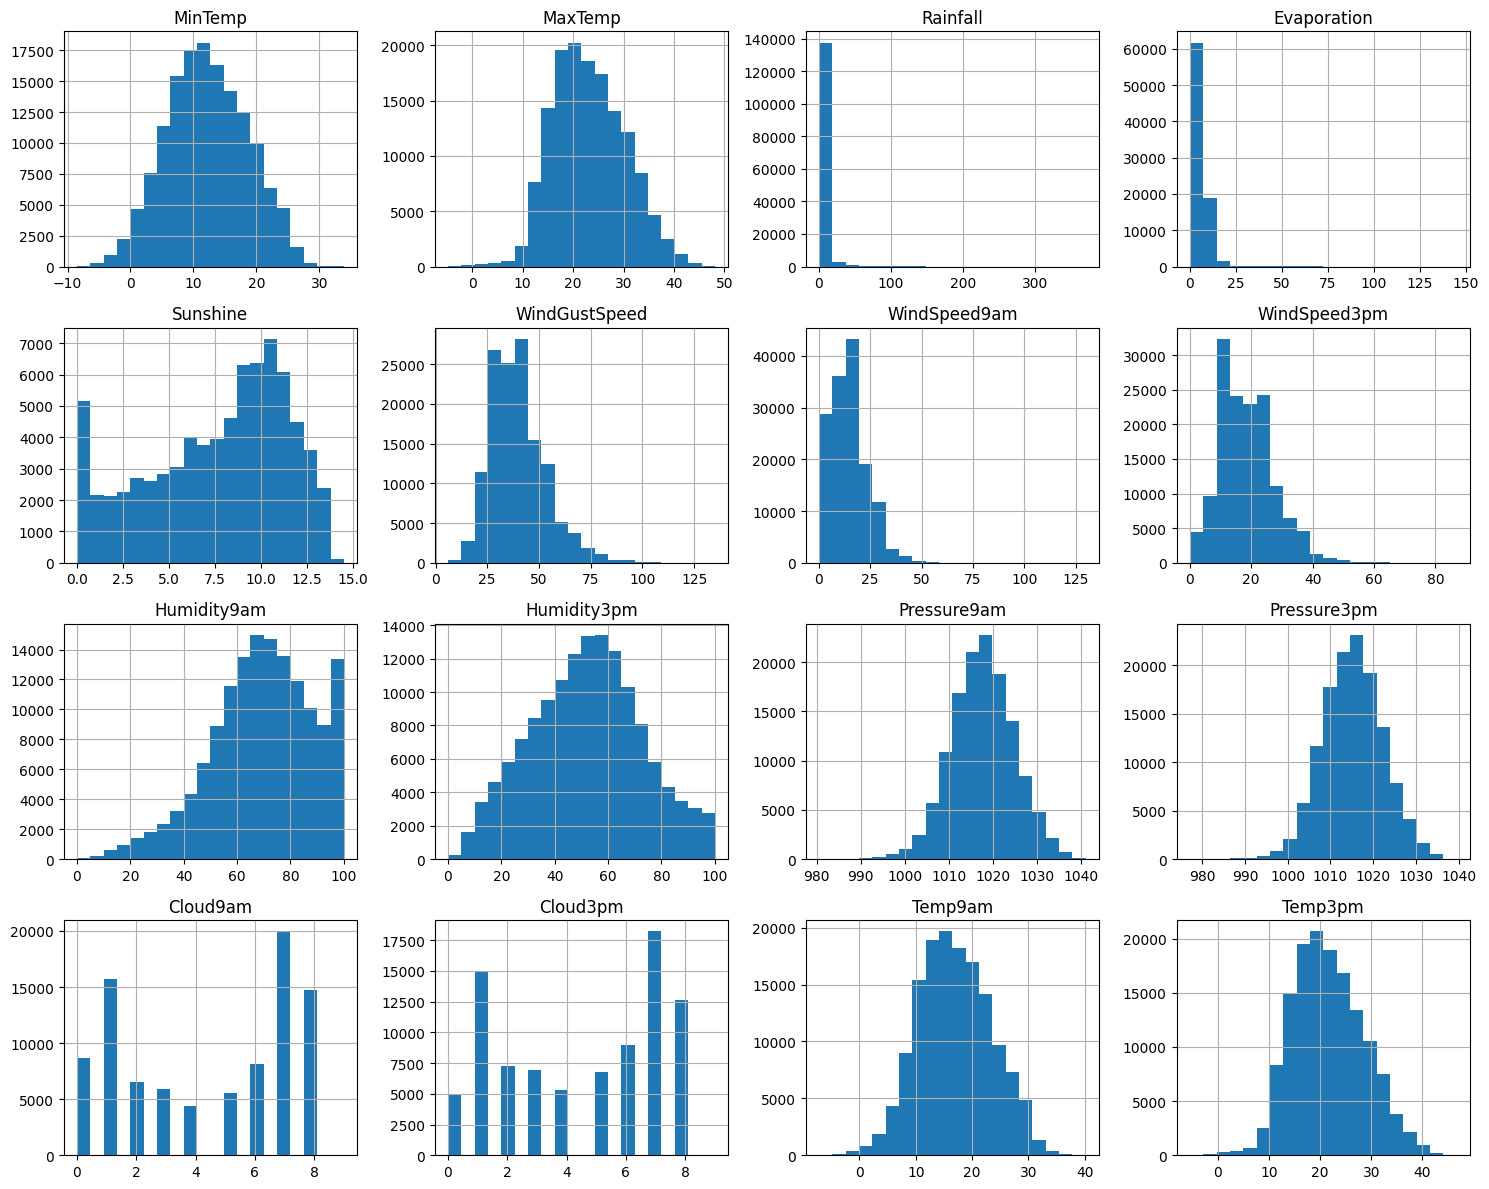

In [ ]:
numeric_data.hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

Inference: The histograms show that MinTemp and MaxTemp are relatively concentrated, while Rainfall has a long right tail. Rainfall has a mean of 2.36 compared with a maximum value of 371.0, indicating a highly spread distribution.

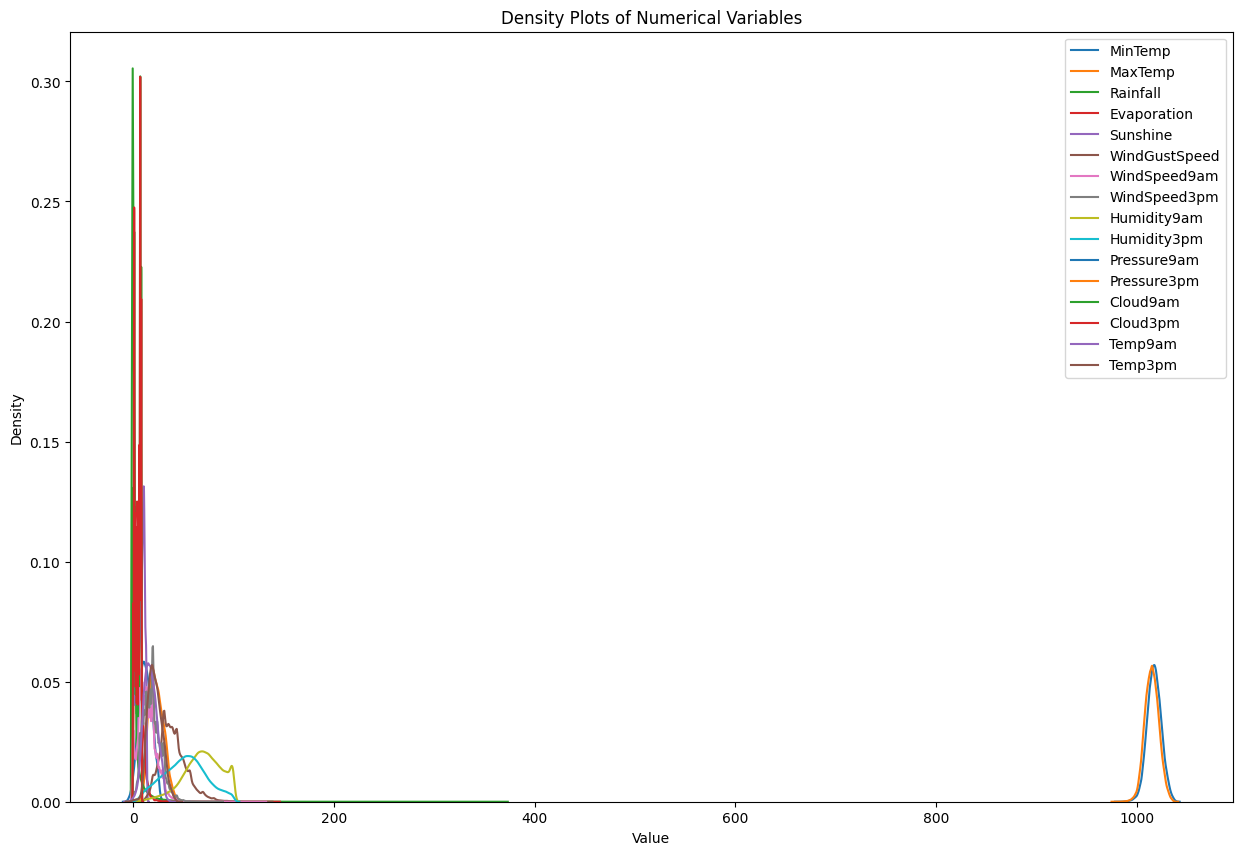

In [ ]:
plt.figure(figsize=(15, 10))

for column in numeric_data.columns:
    sns.kdeplot(
        df[column].dropna(),
        label=column
    )

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Density Plots of Numerical Variables")
plt.legend()
plt.show()

Pressure (~1000+) sits far from all other variables (0–100), so the combined plot is hard to read. Variables with different scales should be plotted separately or standardised.

In [ ]:
print("Skewness:")
print(numeric_data.skew())

Skewness:
MinTemp          0.021188
MaxTemp          0.220839
Rainfall         9.836225
Evaporation      3.761286
Sunshine        -0.496480
WindGustSpeed    0.874879
WindSpeed9am     0.777630
WindSpeed3pm     0.628215
Humidity9am     -0.483969
Humidity3pm      0.033614
Pressure9am     -0.095524
Pressure3pm     -0.045621
Cloud9am        -0.229082
Cloud3pm        -0.226384
Temp9am          0.088540
Temp3pm          0.237960
dtype: float64


Inference: MinTemp has a skewness of 0.021, indicating an almost symmetric distribution, while MaxTemp has 0.221. Rainfall has the highest skewness of 9.836, showing a strong positive skew.

In [ ]:
Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = (
    (numeric_data < lower_limit) |
    (numeric_data > upper_limit)
)

print("Number of potential outliers:")
print(outliers.sum())

Number of potential outliers:
MinTemp             54
MaxTemp            489
Rainfall         25578
Evaporation       1995
Sunshine             0
WindGustSpeed     3092
WindSpeed9am      1817
WindSpeed3pm      2523
Humidity9am       1425
Humidity3pm          0
Pressure9am       1191
Pressure3pm        919
Cloud9am             0
Cloud3pm             0
Temp9am            262
Temp3pm            764
dtype: int64


The IQR method identified potential outliers in several  variables. Rainfall has the highest number of potential outliers with 25,578 values, followed by WindGustSpeed with 3,092 and WindSpeed3pm with 2,523. Sunshine, Humidity3pm, Cloud9am and Cloud3pm have 0 potential outliers using this method.

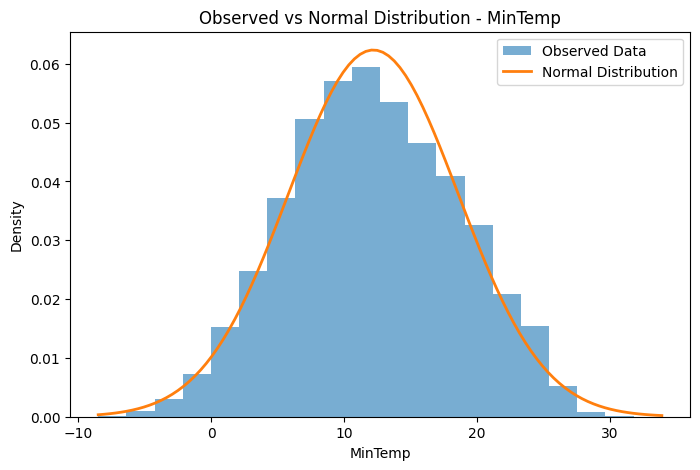

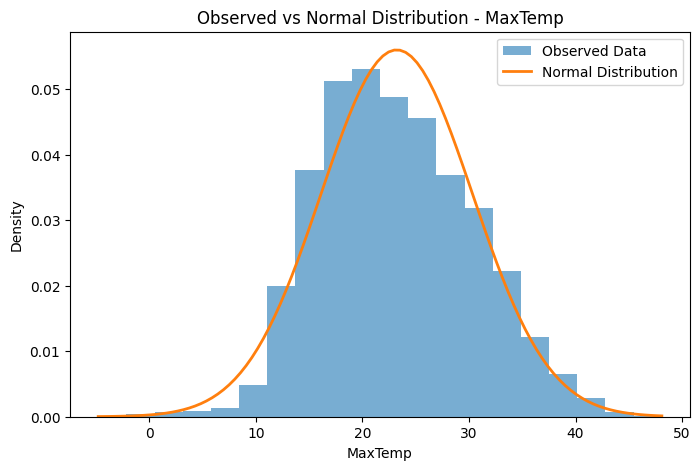

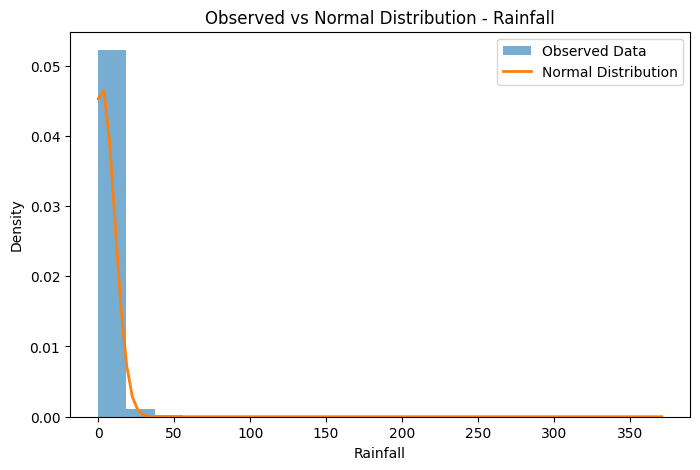

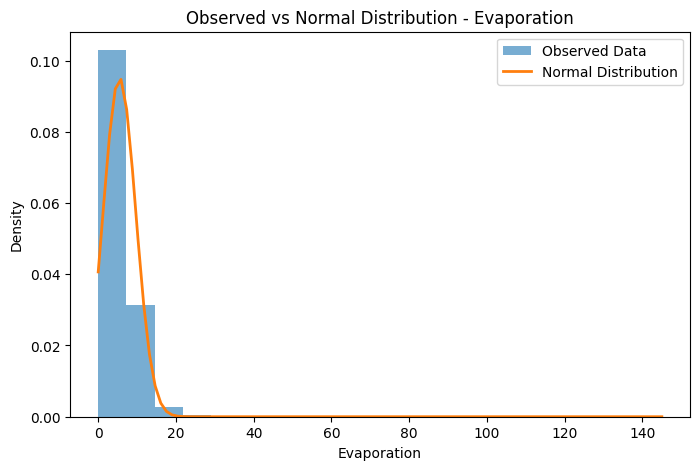

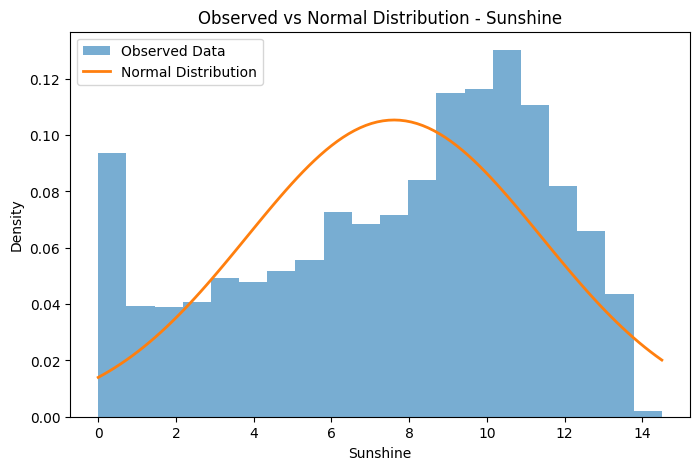

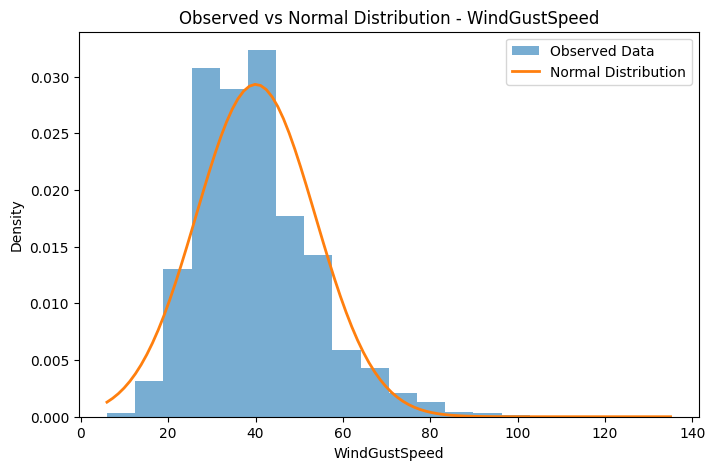

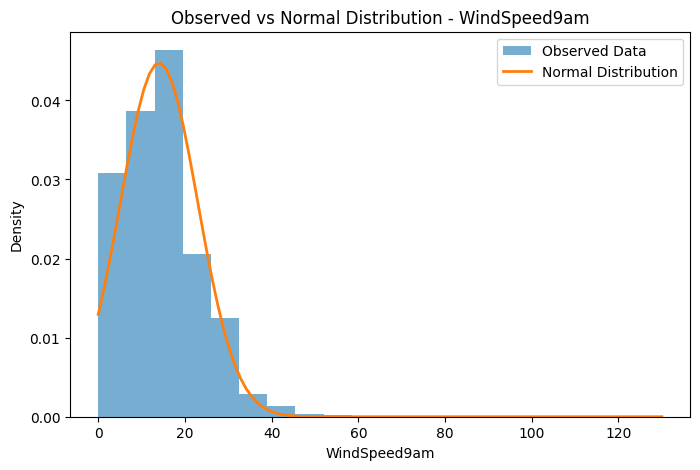

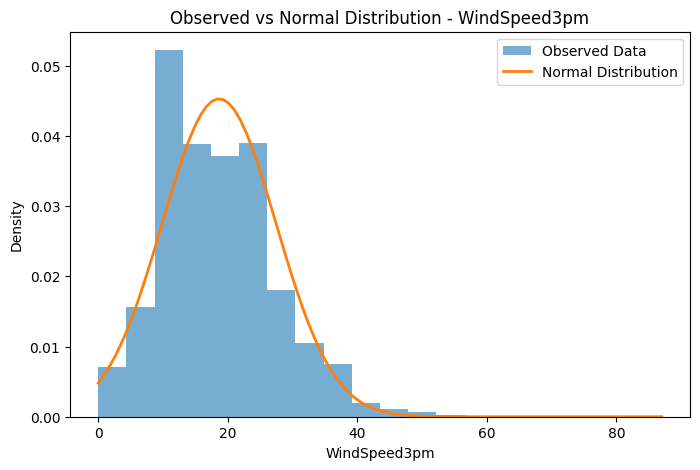

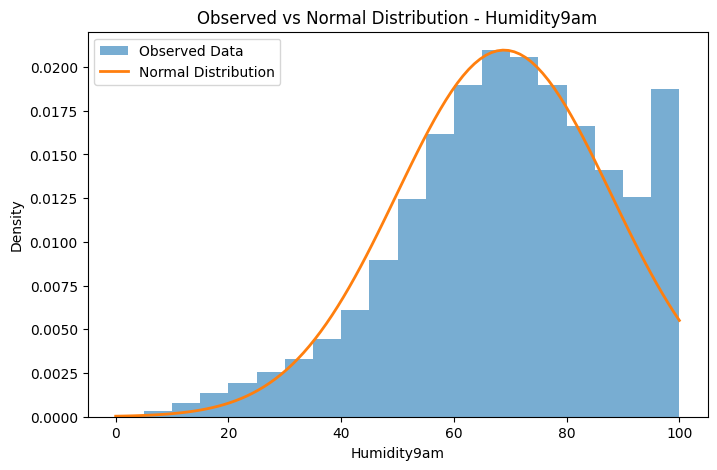

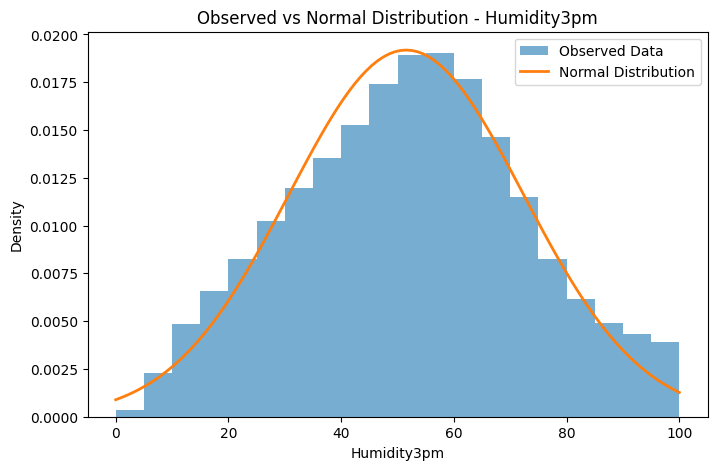

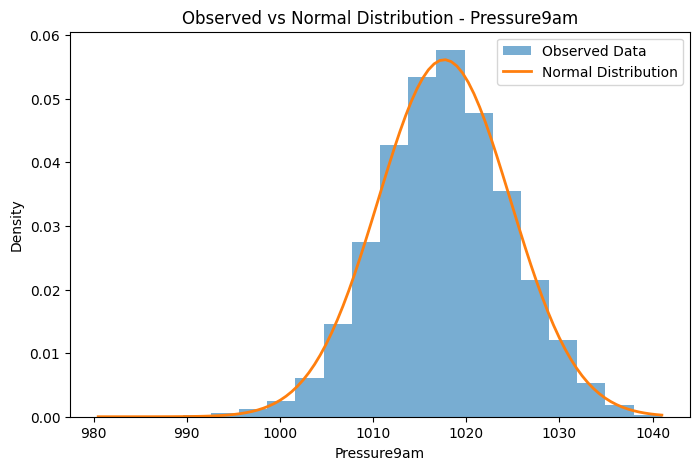

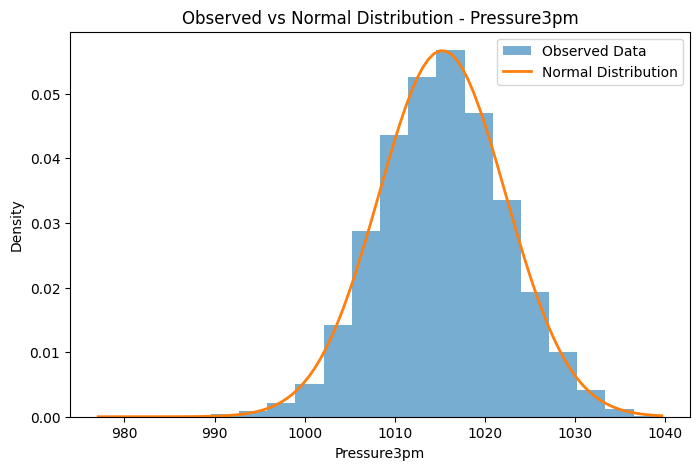

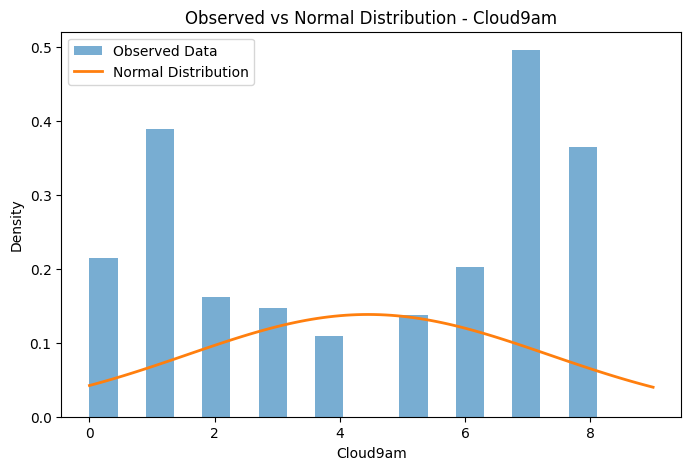

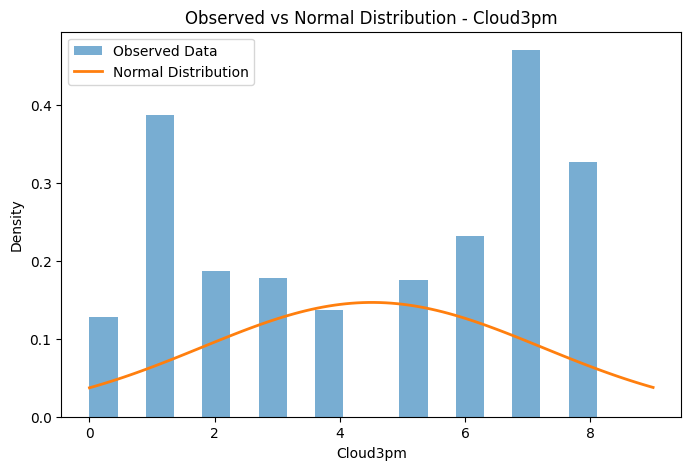

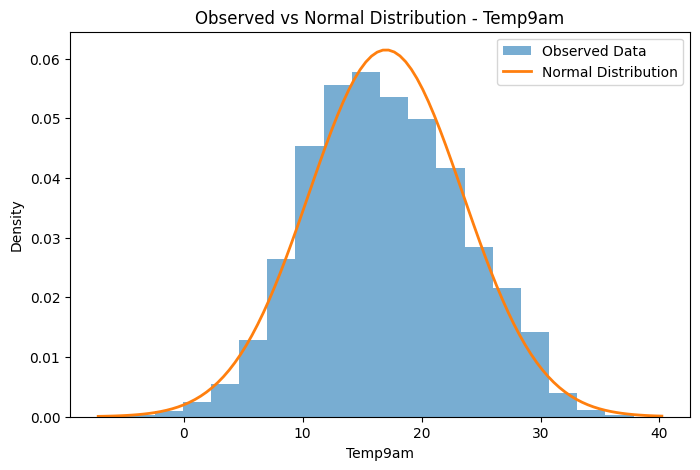

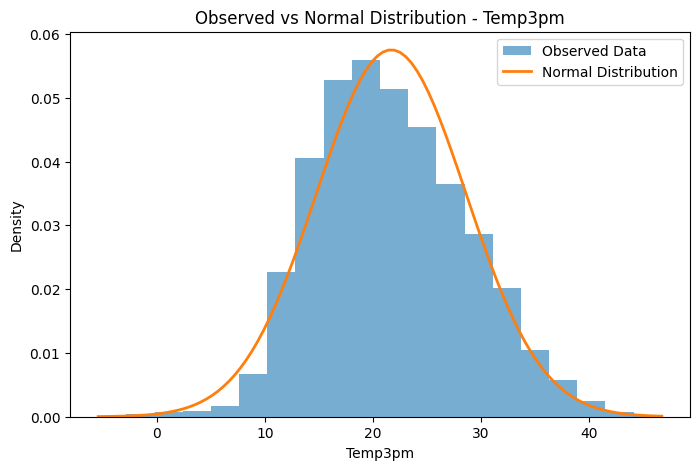

In [ ]:
from scipy.stats import norm

for column in numeric_data.columns:

    data = df[column].dropna()

    mean = data.mean()
    std = data.std()

    x = np.linspace(data.min(), data.max(), 100)

    theoretical = norm.pdf(x, mean, std)

    plt.figure(figsize=(8, 5))

    plt.hist(
        data,
        bins=20,
        density=True,
        alpha=0.6,
        label="Observed Data"
    )

    plt.plot(
        x,
        theoretical,
        linewidth=2,
        label="Normal Distribution"
    )

    plt.xlabel(column)
    plt.ylabel("Density")
    plt.title("Observed vs Normal Distribution - " + column)
    plt.legend()
    plt.show()

Inference: Temperature and pressure variables show a closer fit to the normal distribution, while Rainfall and Evaporation show poorer fits. Rainfall's strong skewness of 9.836 explains why it differs considerably from the normal curve.

In [ ]:
for column in numeric_data.columns:

    skewness = df[column].skew()

    print("\nVariable:", column)
    print("Skewness:", round(skewness, 3))

    if abs(skewness) < 0.5:
        print("Distribution is approximately symmetric.")

    elif skewness > 0:
        print("Distribution is positively skewed.")

    else:
        print("Distribution is negatively skewed.")


Variable: MinTemp
Skewness: 0.021
Distribution is approximately symmetric.

Variable: MaxTemp
Skewness: 0.221
Distribution is approximately symmetric.

Variable: Rainfall
Skewness: 9.836
Distribution is positively skewed.

Variable: Evaporation
Skewness: 3.761
Distribution is positively skewed.

Variable: Sunshine
Skewness: -0.496
Distribution is approximately symmetric.

Variable: WindGustSpeed
Skewness: 0.875
Distribution is positively skewed.

Variable: WindSpeed9am
Skewness: 0.778
Distribution is positively skewed.

Variable: WindSpeed3pm
Skewness: 0.628
Distribution is positively skewed.

Variable: Humidity9am
Skewness: -0.484
Distribution is approximately symmetric.

Variable: Humidity3pm
Skewness: 0.034
Distribution is approximately symmetric.

Variable: Pressure9am
Skewness: -0.096
Distribution is approximately symmetric.

Variable: Pressure3pm
Skewness: -0.046
Distribution is approximately symmetric.

Variable: Cloud9am
Skewness: -0.229
Distribution is approximately symmetric

Inference: MinTemp (0.021), MaxTemp (0.221) and Temp9am (0.089) are approximately symmetric based on skewness. Rainfall (9.836), Evaporation (3.761) and WindGustSpeed (0.875) are positively skewed.

The results show that MinTemp, MaxTemp, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am and Temp3pm are approximately symmetric according to the skewness criterion used in the code.

Rainfall, Evaporation, WindGustSpeed, WindSpeed9am and WindSpeed3pm are positively skewed. Rainfall is the most strongly skewed variable with a skewness of 9.836.